<div style="background: linear-gradient(135deg,#141e30,#243b55); padding:30px; border-radius:15px; color:white; font-family:Arial;">

<h1 style="text-align:center; color:#00E5FF;"> Memory Decay Predictor</h1>

<h3 style="text-align:center; color:#FFD54F;">
Predicting Human Forgetting using Machine Learning
</h3>

<hr style="border:2px solid #00E5FF;">

<h2 style="color:#FFD54F;"> Overview</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
This project explores the science of <strong>human memory and forgetting</strong> using real-world data from 
<strong>Duolingo</strong>. The goal is to build a machine learning model that predicts whether a student will 
<strong>forget a word or concept</strong> based on their learning behavior.
</p>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> The Problem</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
Forgetting is one of the biggest challenges in education. Much of what students learn fades within days.
This phenomenon was first described by <strong>Hermann Ebbinghaus (1885)</strong> through the 
<strong>Forgetting Curve</strong>, which shows that memory decays exponentially over time.
</p>

<p style="color:#FF6B6B;">
The key question:
</p>

<p style="background:#263238; padding:12px; border-radius:8px; color:#B2FF59; text-align:center;">
Can we predict if a student will forget a word before the next review?
</p>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> Challenges</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<ul style="line-height:1.8; color:#8BE9FD;">

<li> <strong>Class Imbalance</strong>  Only 7.32% forgotten vs 92.68% remembered  
<br> → Solved using <strong>upsampling to 50/50 balance</strong></li>

<li> <strong>Overfitting Risk</strong>  Checked using learning curves  
<br> → Generalization gap: <strong>4.28%</strong> (healthy)</li>

<li> <strong>Data Leakage</strong>  Verified no feature had suspicious correlation  
<br> → Max correlation: <strong>&lt; 7%</strong></li>

</ul>

</div>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> The Solution</h2>

<div style="background:#1e293b; padding:20px; border-radius:10px;">

<ul style="line-height:1.8; color:#8BE9FD;">
<li> Logistic Regression</li>
<li> Random Forest</li>
<li> Gradient Boosting</li>
</ul>

<p style="color:#B2FF59;">
 <strong>Random Forest</strong> achieved the best performance:
</p>

<p style="background:#263238; padding:12px; border-radius:8px; color:#00E676; text-align:center;">
Accuracy: <strong>94.55%</strong> &nbsp; | &nbsp; AUC-ROC: <strong>97.69%</strong>
</p>

</div>

<hr style="border:1px dashed #FFD54F;">

<h2 style="color:#FFD54F;"> Key Takeaway</h2>

<p style="color:#FF6B6B; font-size:16px; line-height:1.6;">
The strongest predictors of forgetting were:
</p>

<ul style="line-height:1.8;">
<li> <strong>Memory Strength</strong>  historical accuracy</li>
<li> <strong>Days Since Last Review</strong></li>
</ul>

<p style="color:#FF6B6B;">
This confirms <strong>Ebbinghaus theory</strong> and highlights the power of 
<strong>spaced repetition</strong> for long-term learning.
</p>

</div>

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Imports
</h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

print("All libraries loaded successfully.")


All libraries loaded successfully.


<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Load Dataset
</h2>

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aravinii/duolingo-spaced-repetition-data/learning_traces.13m.csv",
                 nrows=100000)

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (100000, 12)

Column Names:
['p_recall', 'timestamp', 'delta', 'user_id', 'learning_language', 'ui_language', 'lexeme_id', 'lexeme_string', 'history_seen', 'history_correct', 'session_seen', 'session_correct']

First 5 Rows:


,p_recall,timestamp,delta,user_id,learning_language,ui_language,lexeme_id,lexeme_string,history_seen,history_correct,session_seen,session_correct
0,1.0,1362076081,27649635,u:FO,de,en,76390c1350a8dac31186187e2fe1e178,lernt/lernen<vblex><pri><p3><sg>,6,4,2,2
1,0.5,1362076081,27649635,u:FO,de,en,7dfd7086f3671685e2cf1c1da72796d7,die/die<det><def><f><sg><nom>,4,4,2,1
2,1.0,1362076081,27649635,u:FO,de,en,35a54c25a2cda8127343f6a82e6f6b7d,mann/mann<n><m><sg><nom>,5,4,1,1
3,0.5,1362076081,27649635,u:FO,de,en,0cf63ffe3dda158bc3dbd55682b355ae,frau/frau<n><f><sg><nom>,6,5,2,1
4,1.0,1362076081,27649635,u:FO,de,en,84920990d78044db53c1b012f5bf9ab5,das/das<det><def><nt><sg><nom>,4,4,1,1


<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Dataset Overview & Info
</h2>

In [3]:
print("Dataset Info:")
print(df.info())

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   p_recall           100000 non-null  float64
 1   timestamp          100000 non-null  int64  
 2   delta              100000 non-null  int64  
 3   user_id            100000 non-null  object 
 4   learning_language  100000 non-null  object 
 5   ui_language        100000 non-null  object 
 6   lexeme_id          100000 non-null  object 
 7   lexeme_string      100000 non-null  object 
 8   history_seen       100000 non-null  int64  
 9   history_correct    100000 non-null  int64  
 10  session_seen       100000 non-null  int64  
 11  session_correct    100000 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 9.2+ MB
None

Missing Values Per Column:
p_recall             0
timestamp            0
delta                0
user_id              0
lea

,p_recall,timestamp,delta,history_seen,history_correct,session_seen,session_correct
count,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.898076,1.362085e+09,6.433793e+05,20.216200,18.267160,1.758390,1.593110
std,0.271232,1.406585e+03,2.164767e+06,80.726896,73.022359,1.310508,1.274491
min,0.000000,1.362076e+09,1.000000e+00,1.000000,1.000000,1.000000,0.000000
25%,1.000000,1.362084e+09,5.260000e+02,3.000000,3.000000,1.000000,1.000000
50%,1.000000,1.362085e+09,7.732200e+04,6.000000,6.000000,1.000000,1.000000
75%,1.000000,1.362086e+09,3.495870e+05,15.000000,13.000000,2.000000,2.000000
max,1.000000,1.362087e+09,3.275106e+07,2791.000000,2406.000000,20.000000,19.000000


<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Data Cleaning & Feature Engineering
</h2>

In [4]:
df = df.dropna()

df["delta_days"] = df["delta"] / 86400

df["memory_strength"] = df["history_correct"] / (df["history_seen"] + 1)

df["forgotten"] = (df["p_recall"] < 0.5).astype(int)

df["lag_category"] = pd.cut(df["delta_days"],
                             bins=[-1, 1, 7, 30, 365, 9999],
                             labels=["Same Day", "1 Week", "1 Month", "1 Year", "Over 1 Year"])

print("Cleaned Dataset Shape:", df.shape)
print("\nForgotten Distribution:")
print(df["forgotten"].value_counts())
print("\nForgotten Rate: {:.2f}%".format(df["forgotten"].mean() * 100))

Cleaned Dataset Shape: (100000, 16)

Forgotten Distribution:
forgotten
0    92685
1     7315
Name: count, dtype: int64

Forgotten Rate: 7.32%


<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 EDA: Target Distribution
</h2>

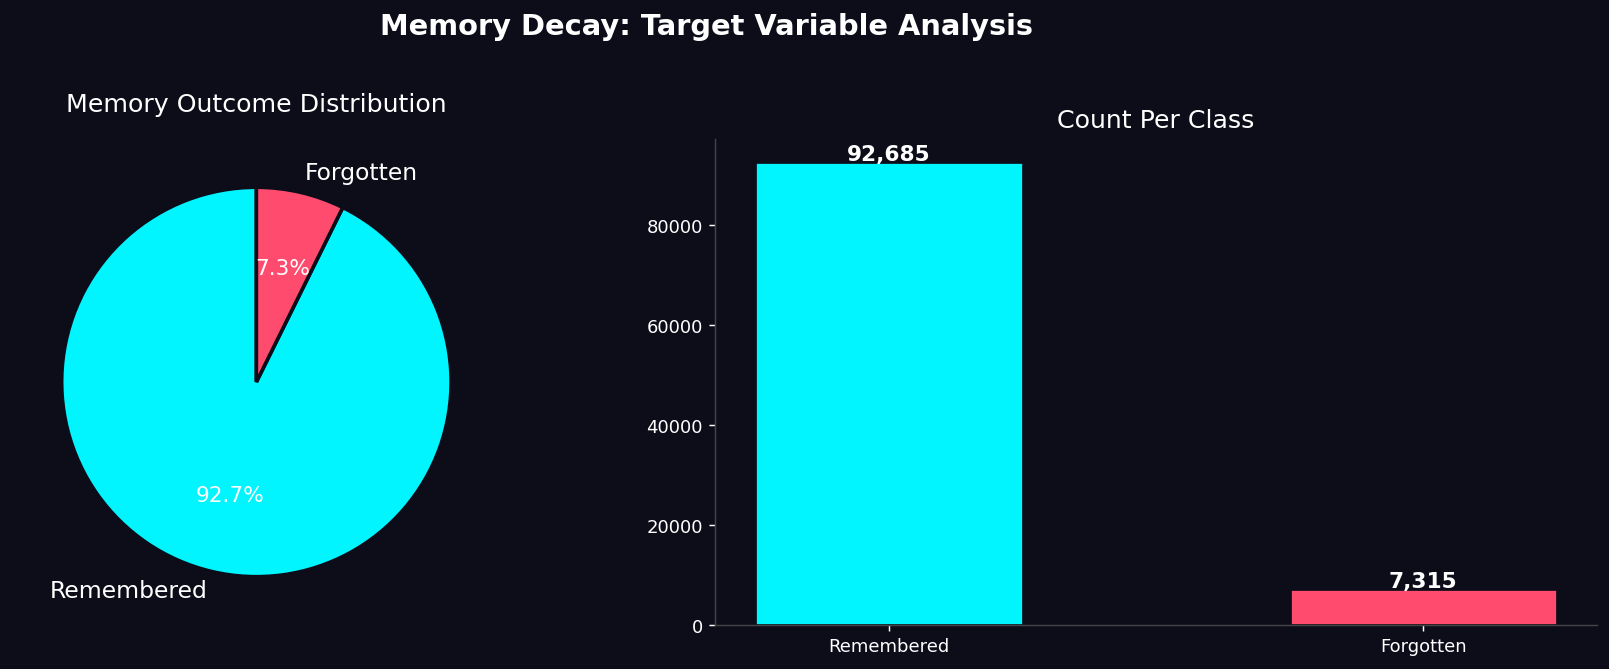

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0D0D1A")

colors_pie = ["#00F5FF", "#FF4B6E"]
counts = df["forgotten"].value_counts()
labels = ["Remembered", "Forgotten"]

axes[0].set_facecolor("#0D0D1A")
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors_pie,
    startangle=90,
    wedgeprops=dict(edgecolor="#0D0D1A", linewidth=2),
    textprops=dict(color="white", fontsize=13)
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color("white")
axes[0].set_title("Memory Outcome Distribution", color="white", fontsize=14, pad=15)

axes[1].set_facecolor("#0D0D1A")
bar_colors = ["#00F5FF", "#FF4B6E"]
bars = axes[1].bar(labels, counts.values, color=bar_colors, edgecolor="#0D0D1A", linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                 f"{val:,}", ha="center", color="white", fontsize=12, fontweight="bold")
axes[1].set_facecolor("#0D0D1A")
axes[1].tick_params(colors="white")
axes[1].spines["bottom"].set_color("#444")
axes[1].spines["left"].set_color("#444")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].set_title("Count Per Class", color="white", fontsize=14)
axes[1].yaxis.label.set_color("white")

fig.suptitle("Memory Decay: Target Variable Analysis", color="white", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("target_distribution.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
EDA: Recall Rate Over Time (Forgetting Curve)
</h2>

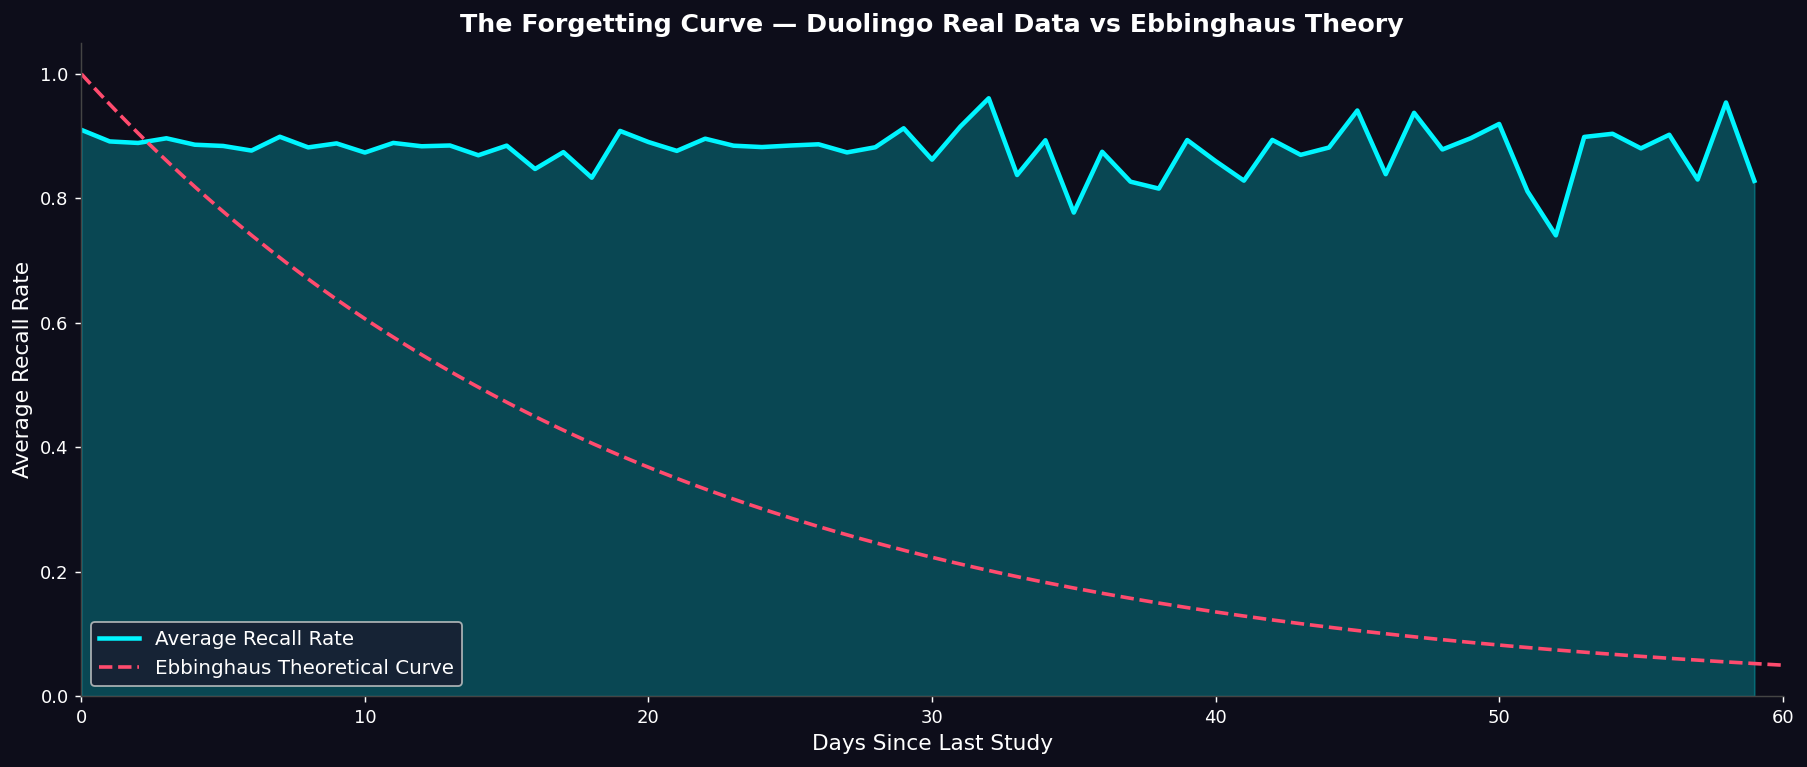

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")

decay_curve = df[df["delta_days"] <= 60].groupby(df["delta_days"].astype(int))["p_recall"].mean()

ax.fill_between(decay_curve.index, decay_curve.values,
                alpha=0.25, color="#00F5FF")
ax.plot(decay_curve.index, decay_curve.values,
        color="#00F5FF", linewidth=2.5, label="Average Recall Rate")

t = np.linspace(0, 60, 300)
ebbinghaus = np.exp(-t / 20)
ax.plot(t, ebbinghaus, color="#FF4B6E", linewidth=2,
        linestyle="--", label="Ebbinghaus Theoretical Curve")

ax.set_xlabel("Days Since Last Study", color="white", fontsize=12)
ax.set_ylabel("Average Recall Rate", color="white", fontsize=12)
ax.set_title("The Forgetting Curve — Duolingo Real Data vs Ebbinghaus Theory",
             color="white", fontsize=14, fontweight="bold")
ax.tick_params(colors="white")
ax.spines["bottom"].set_color("#444")
ax.spines["left"].set_color("#444")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(facecolor="#1A1A2E", labelcolor="white", fontsize=11)
ax.set_xlim(0, 60)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("forgetting_curve.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
EDA: Memory Strength vs Recall
</h2>

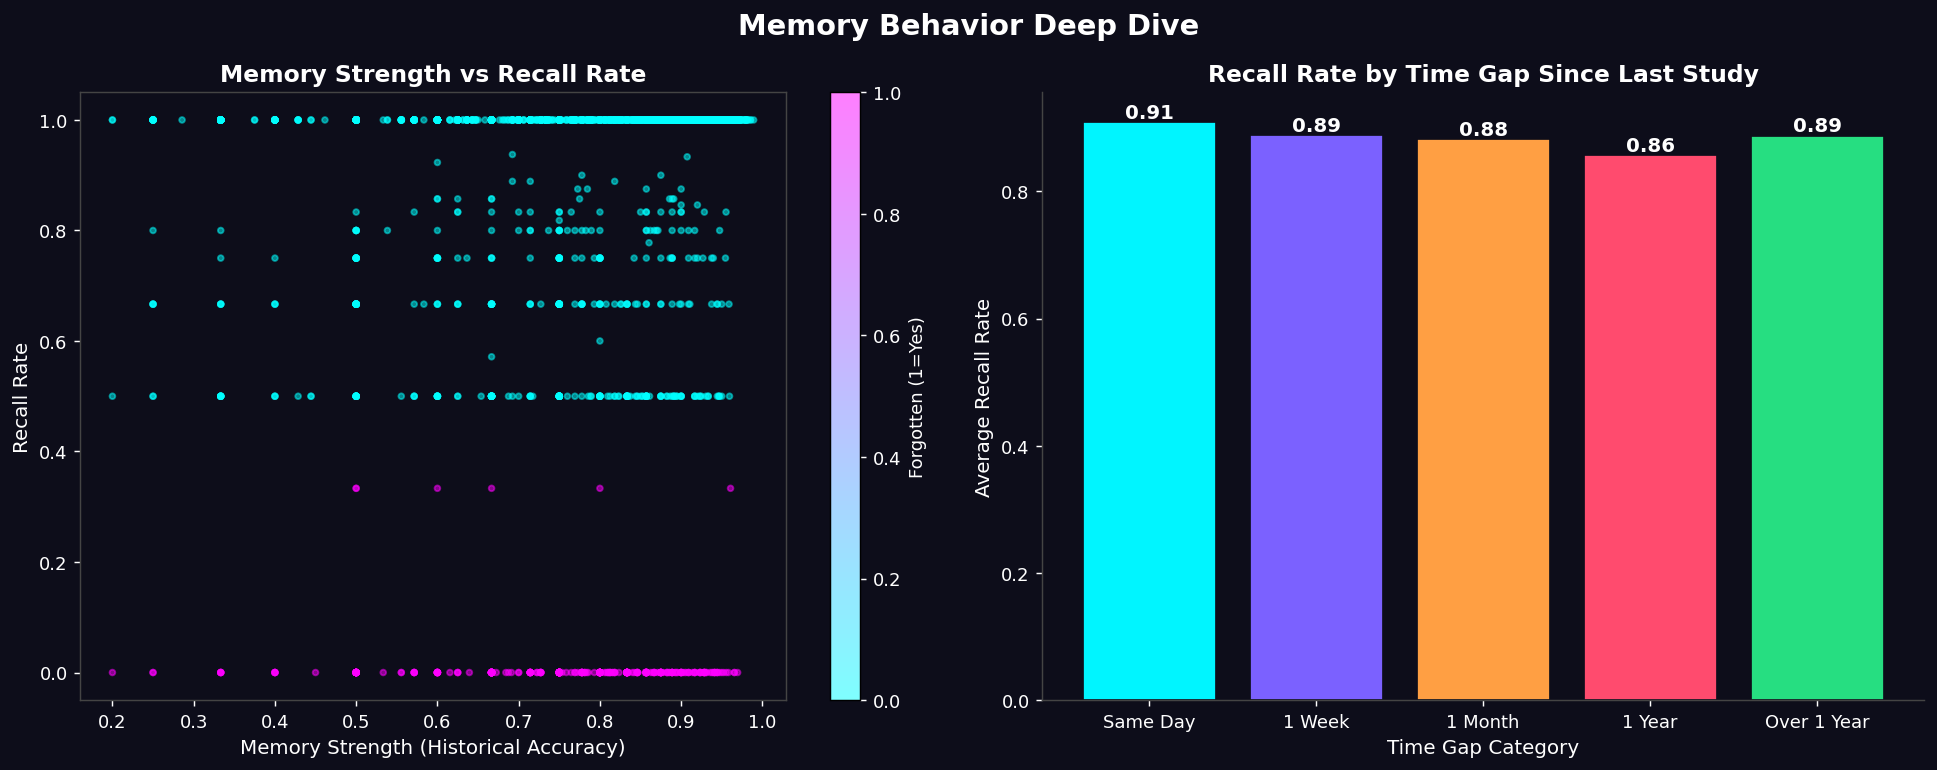

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#0D0D1A")

axes[0].set_facecolor("#0D0D1A")
scatter = axes[0].scatter(
    df["memory_strength"].sample(5000, random_state=42),
    df["p_recall"].sample(5000, random_state=42),
    c=df["forgotten"].sample(5000, random_state=42),
    cmap="cool",
    alpha=0.5,
    s=10
)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label("Forgotten (1=Yes)", color="white")
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
axes[0].set_xlabel("Memory Strength (Historical Accuracy)", color="white", fontsize=11)
axes[0].set_ylabel("Recall Rate", color="white", fontsize=11)
axes[0].set_title("Memory Strength vs Recall Rate", color="white", fontsize=13, fontweight="bold")
axes[0].tick_params(colors="white")
for sp in axes[0].spines.values():
    sp.set_color("#444")

axes[1].set_facecolor("#0D0D1A")
palette = {"Same Day": "#00F5FF", "1 Week": "#7B61FF",
           "1 Month": "#FF9F43", "1 Year": "#FF4B6E", "Over 1 Year": "#26de81"}
lag_recall = df.groupby("lag_category")["p_recall"].mean()
bar_vals = [lag_recall.get(k, 0) for k in palette.keys()]
bars = axes[1].bar(palette.keys(), bar_vals,
                   color=list(palette.values()),
                   edgecolor="#0D0D1A", linewidth=1.5)
for bar, val in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f"{val:.2f}", ha="center", color="white", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Time Gap Category", color="white", fontsize=11)
axes[1].set_ylabel("Average Recall Rate", color="white", fontsize=11)
axes[1].set_title("Recall Rate by Time Gap Since Last Study", color="white", fontsize=13, fontweight="bold")
axes[1].tick_params(colors="white", axis="both")
for sp in axes[1].spines.values():
    sp.set_color("#444")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

fig.suptitle("Memory Behavior Deep Dive", color="white", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("memory_strength.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
EDA: Correlation Heatmap
</h2>

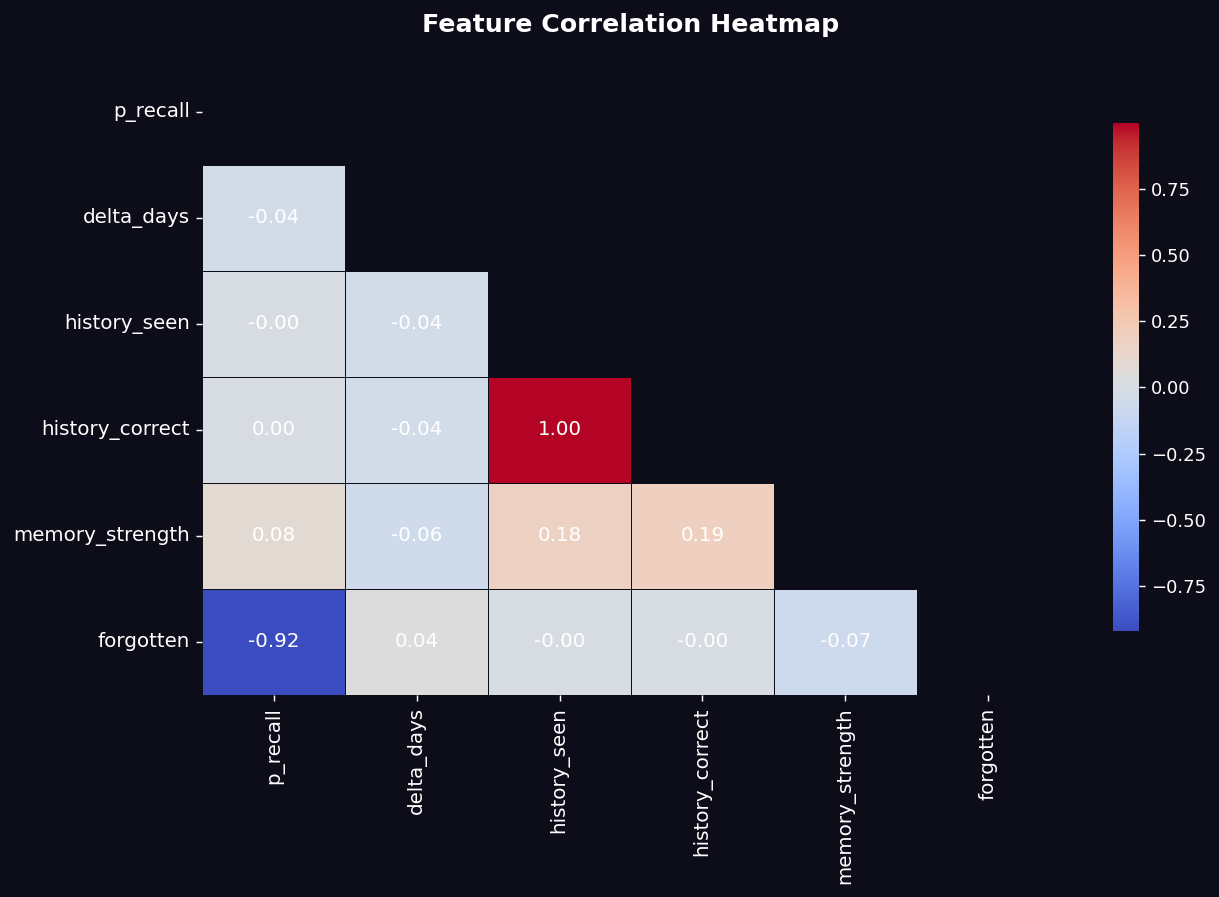

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")

num_cols = ["p_recall", "delta_days", "history_seen", "history_correct",
            "memory_strength", "forgotten"]
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            linewidths=0.5,
            linecolor="#0D0D1A",
            ax=ax,
            annot_kws={"size": 11, "color": "white"},
            cbar_kws={"shrink": 0.8})

ax.set_title("Feature Correlation Heatmap", color="white", fontsize=14,
             fontweight="bold", pad=15)
ax.tick_params(colors="white", labelsize=11)
ax.figure.axes[-1].tick_params(colors="white")

plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
EDA: Distribution of Key Features
</h2>

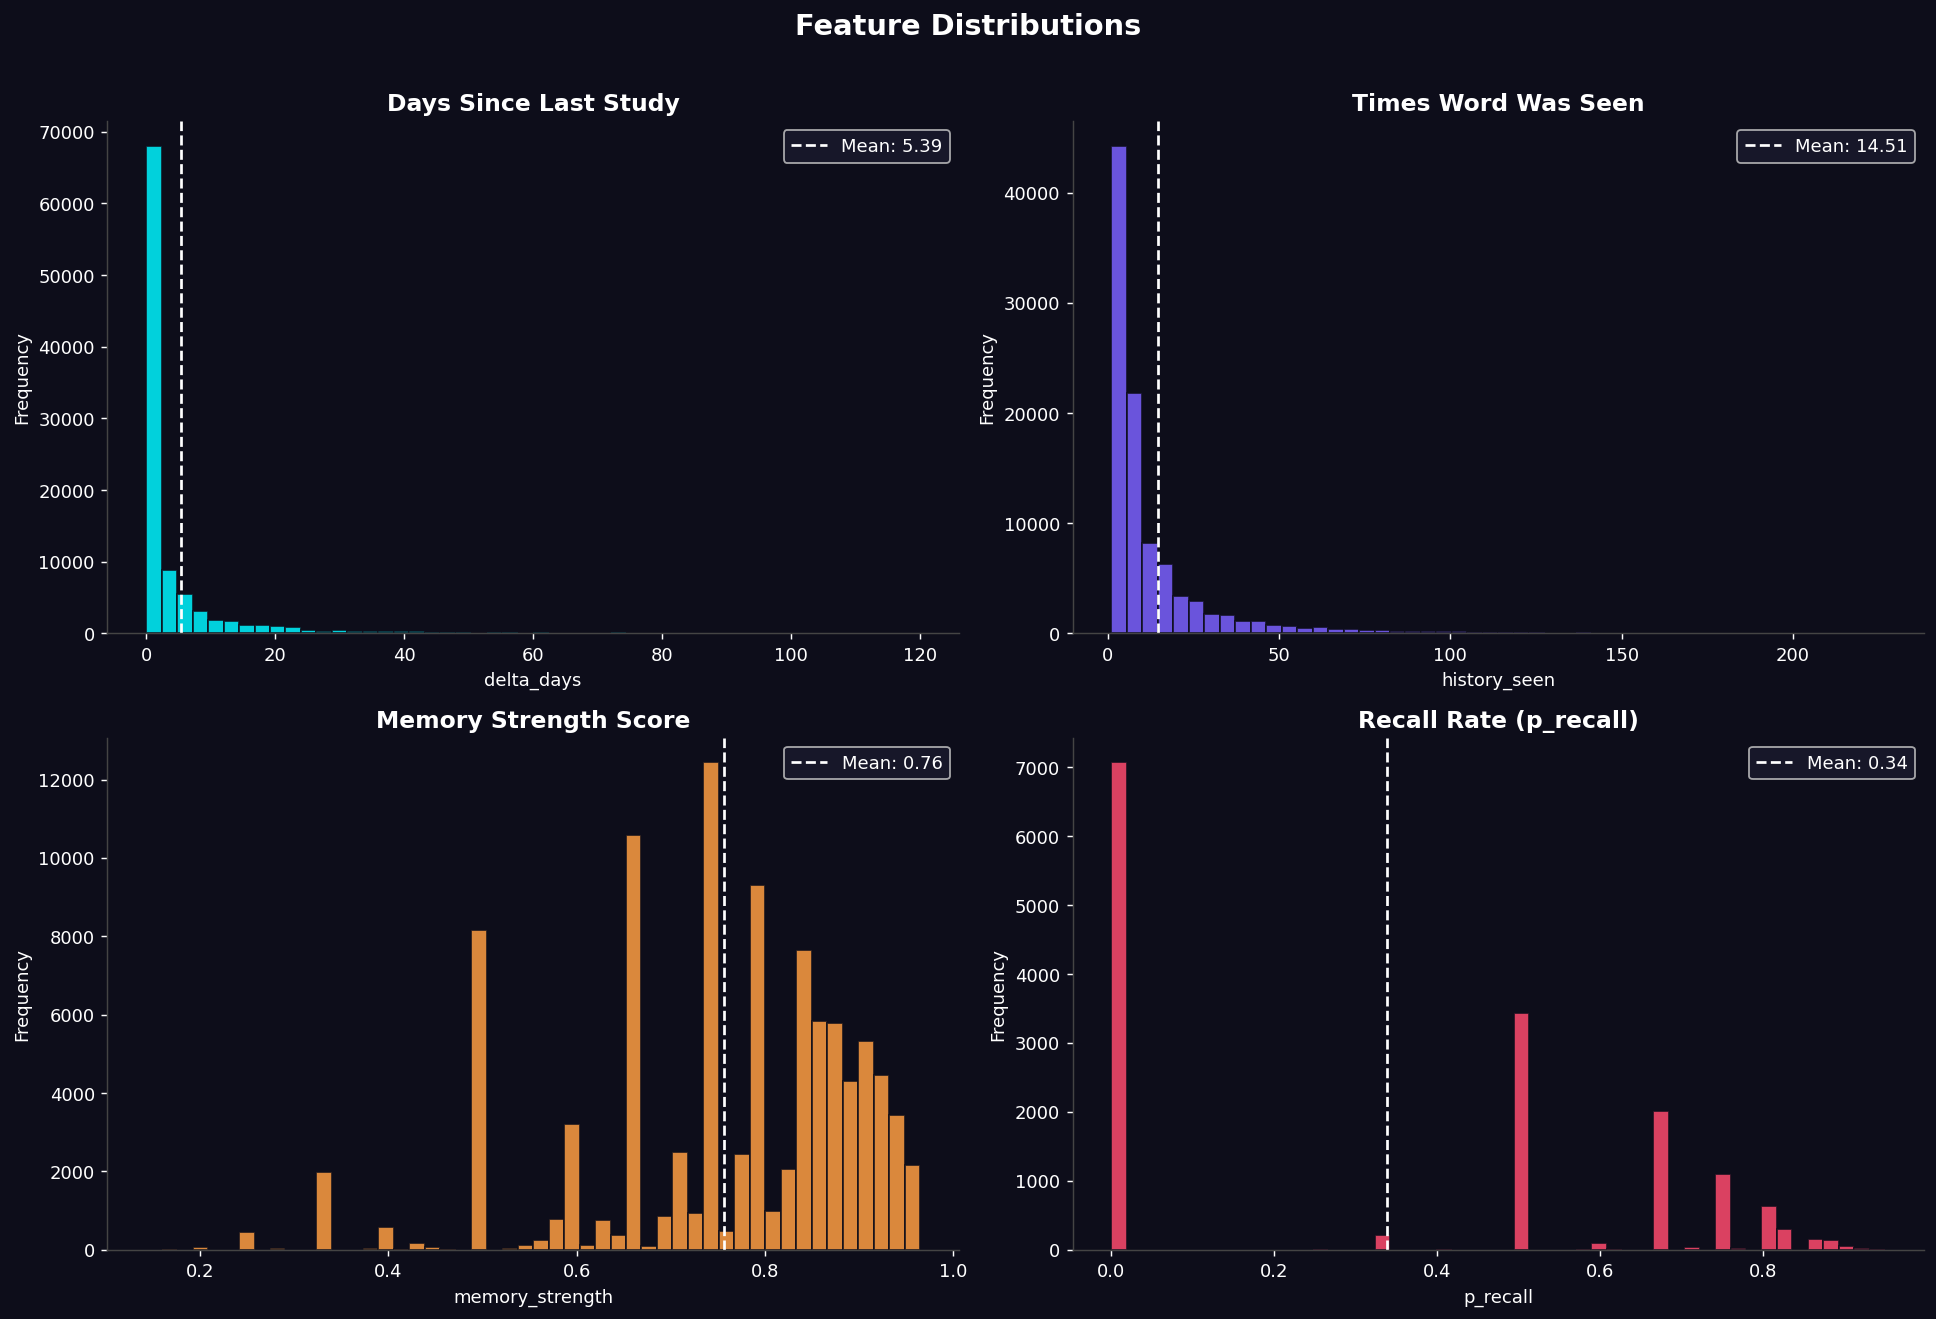

In [9]:
features_to_plot = ["delta_days", "history_seen", "memory_strength", "p_recall"]
titles = ["Days Since Last Study", "Times Word Was Seen",
          "Memory Strength Score", "Recall Rate (p_recall)"]
grad_colors = ["#00F5FF", "#7B61FF", "#FF9F43", "#FF4B6E"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.patch.set_facecolor("#0D0D1A")
axes = axes.flatten()

for i, (col, title, color) in enumerate(zip(features_to_plot, titles, grad_colors)):
    axes[i].set_facecolor("#0D0D1A")
    data = df[col].dropna()
    data = data[data < data.quantile(0.99)]
    axes[i].hist(data, bins=50, color=color, alpha=0.85, edgecolor="#0D0D1A")
    axes[i].axvline(data.mean(), color="white", linestyle="--", linewidth=1.5,
                    label=f"Mean: {data.mean():.2f}")
    axes[i].set_title(title, color="white", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(col, color="white", fontsize=10)
    axes[i].set_ylabel("Frequency", color="white", fontsize=10)
    axes[i].tick_params(colors="white")
    axes[i].legend(facecolor="#1A1A2E", labelcolor="white", fontsize=10)
    for sp in ["top", "right"]:
        axes[i].spines[sp].set_visible(False)
    for sp in ["bottom", "left"]:
        axes[i].spines[sp].set_color("#444")

fig.suptitle("Feature Distributions", color="white", fontsize=16,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_distributions.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
Prepare Features for ML
</h2>

In [10]:
from sklearn.utils import resample

feature_cols = ["delta_days", "history_seen", "history_correct", "memory_strength"]
target_col = "forgotten"

X = df[feature_cols].copy()
y = df[target_col].copy()

df_majority = df[df["forgotten"] == 0]
df_minority = df[df["forgotten"] == 1]

df_minority_upsampled = resample(df_minority,
                                  replace=True,
                                  n_samples=len(df_majority),
                                  random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_balanced = df_balanced[feature_cols]
y_balanced = df_balanced[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training Samples  :", X_train.shape[0])
print("Testing Samples   :", X_test.shape[0])
print("Features Used     :", feature_cols)
print("\nClass Balance After Fix:")
print(pd.Series(y_train).value_counts())
print("\nBalance Ratio     : 50% / 50%")

Training Samples  : 148296
Testing Samples   : 37074
Features Used     : ['delta_days', 'history_seen', 'history_correct', 'memory_strength']

Class Balance After Fix:
forgotten
1    74148
0    74148
Name: count, dtype: int64

Balance Ratio     : 50% / 50%


<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
Train Models
</h2>

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        "model":    model,
        "y_pred":   y_pred,
        "y_proba":  y_proba,
        "accuracy": acc,
        "auc":      auc
    }
    print(f"{name:25s}  Accuracy: {acc:.4f}  |  AUC: {auc:.4f}")

Logistic Regression        Accuracy: 0.5624  |  AUC: 0.5899
Random Forest              Accuracy: 0.9455  |  AUC: 0.9769
Gradient Boosting          Accuracy: 0.5903  |  AUC: 0.6345


<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
Leakage & Overfitting Check
</h2>

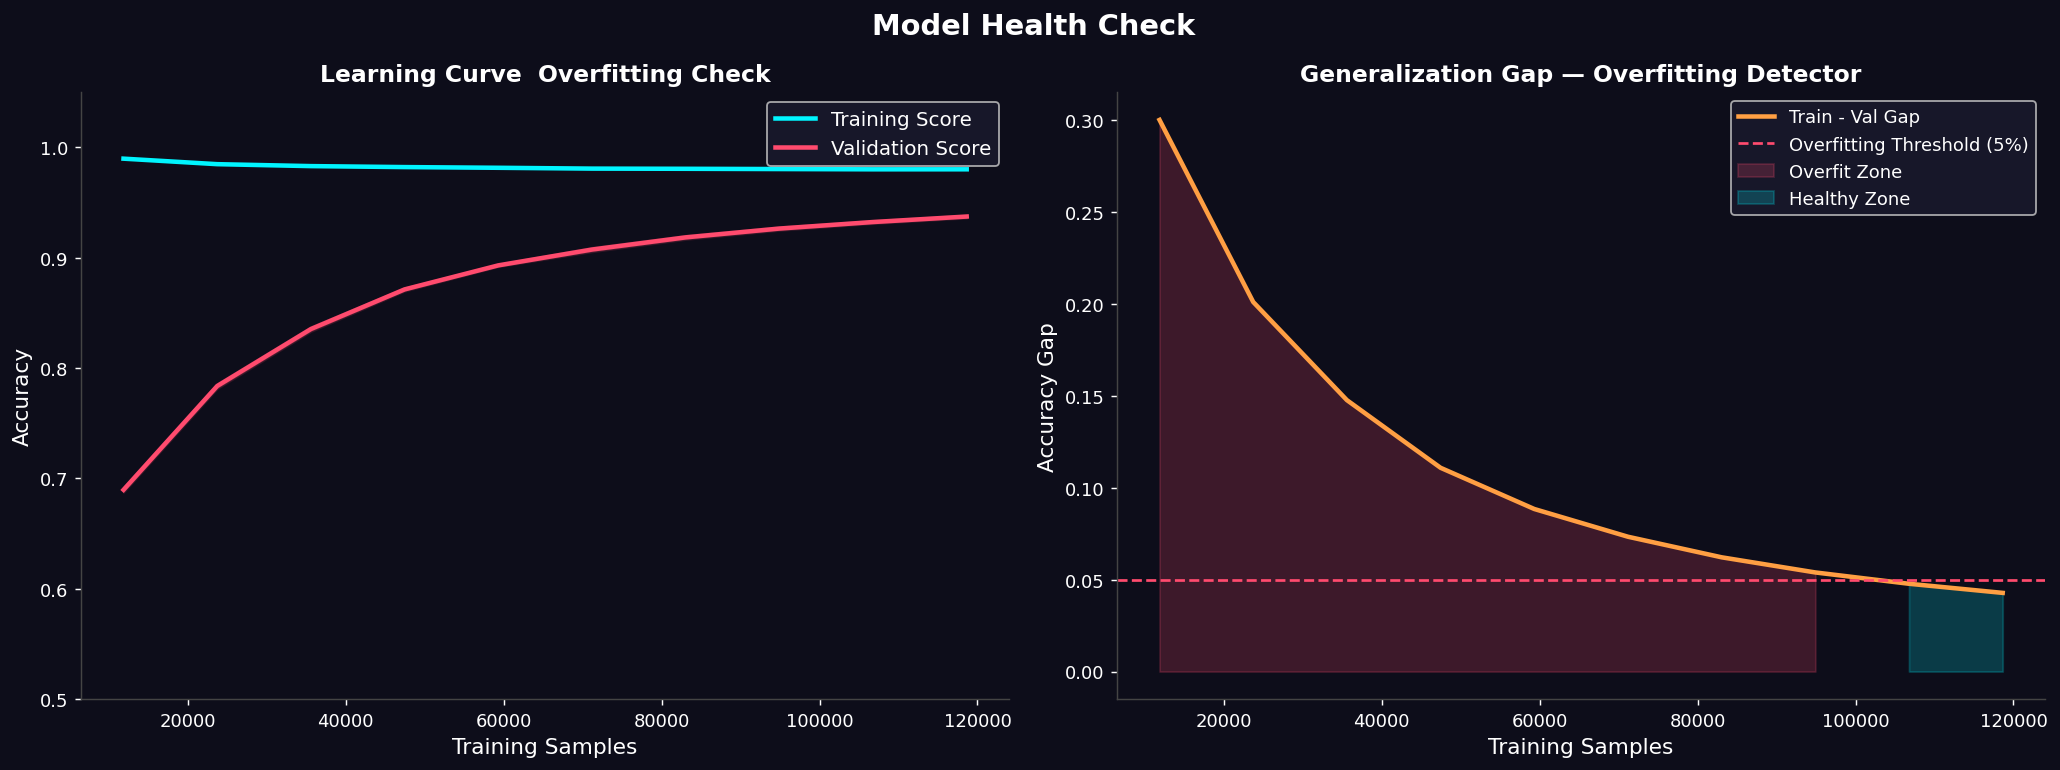

Train Accuracy (final)     : 0.9802
Validation Accuracy (final): 0.9374
Generalization Gap         : 0.0428
Result: No Overfitting Detected  Model is Healthy


In [12]:
from sklearn.model_selection import learning_curve

rf_model = results["Random Forest"]["model"]

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_scaled, y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0D0D1A")

axes[0].set_facecolor("#0D0D1A")
axes[0].plot(train_sizes, train_mean, color="#00F5FF", linewidth=2.5, label="Training Score")
axes[0].fill_between(train_sizes, train_mean - train_std,
                     train_mean + train_std, alpha=0.15, color="#00F5FF")
axes[0].plot(train_sizes, val_mean, color="#FF4B6E", linewidth=2.5, label="Validation Score")
axes[0].fill_between(train_sizes, val_mean - val_std,
                     val_mean + val_std, alpha=0.15, color="#FF4B6E")
axes[0].set_xlabel("Training Samples", color="white", fontsize=12)
axes[0].set_ylabel("Accuracy", color="white", fontsize=12)
axes[0].set_title("Learning Curve  Overfitting Check",
                  color="white", fontsize=13, fontweight="bold")
axes[0].tick_params(colors="white")
axes[0].legend(facecolor="#1A1A2E", labelcolor="white", fontsize=11)
axes[0].set_ylim(0.5, 1.05)
for sp in ["top", "right"]:
    axes[0].spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    axes[0].spines[sp].set_color("#444")

gap = train_mean - val_mean
axes[1].set_facecolor("#0D0D1A")
axes[1].plot(train_sizes, gap, color="#FF9F43", linewidth=2.5, label="Train - Val Gap")
axes[1].axhline(y=0.05, color="#FF4B6E", linestyle="--", linewidth=1.5, label="Overfitting Threshold (5%)")
axes[1].fill_between(train_sizes, 0, gap,
                     where=(gap > 0.05), color="#FF4B6E", alpha=0.2, label="Overfit Zone")
axes[1].fill_between(train_sizes, 0, gap,
                     where=(gap <= 0.05), color="#00F5FF", alpha=0.2, label="Healthy Zone")
axes[1].set_xlabel("Training Samples", color="white", fontsize=12)
axes[1].set_ylabel("Accuracy Gap", color="white", fontsize=12)
axes[1].set_title("Generalization Gap — Overfitting Detector",
                  color="white", fontsize=13, fontweight="bold")
axes[1].tick_params(colors="white")
axes[1].legend(facecolor="#1A1A2E", labelcolor="white", fontsize=10)
for sp in ["top", "right"]:
    axes[1].spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    axes[1].spines[sp].set_color("#444")

fig.suptitle("Model Health Check", color="white", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("overfitting_check.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

gap_final = train_mean[-1] - val_mean[-1]
print("Train Accuracy (final)     :", round(train_mean[-1], 4))
print("Validation Accuracy (final):", round(val_mean[-1], 4))
print("Generalization Gap         :", round(gap_final, 4))

if gap_final < 0.05:
    print("Result: No Overfitting Detected  Model is Healthy")
elif gap_final < 0.10:
    print("Result: Slight Overfitting  Still Acceptable")
else:
    print("Result: Overfitting Detected  Needs Fixing")

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Leakage Check:
</h2>

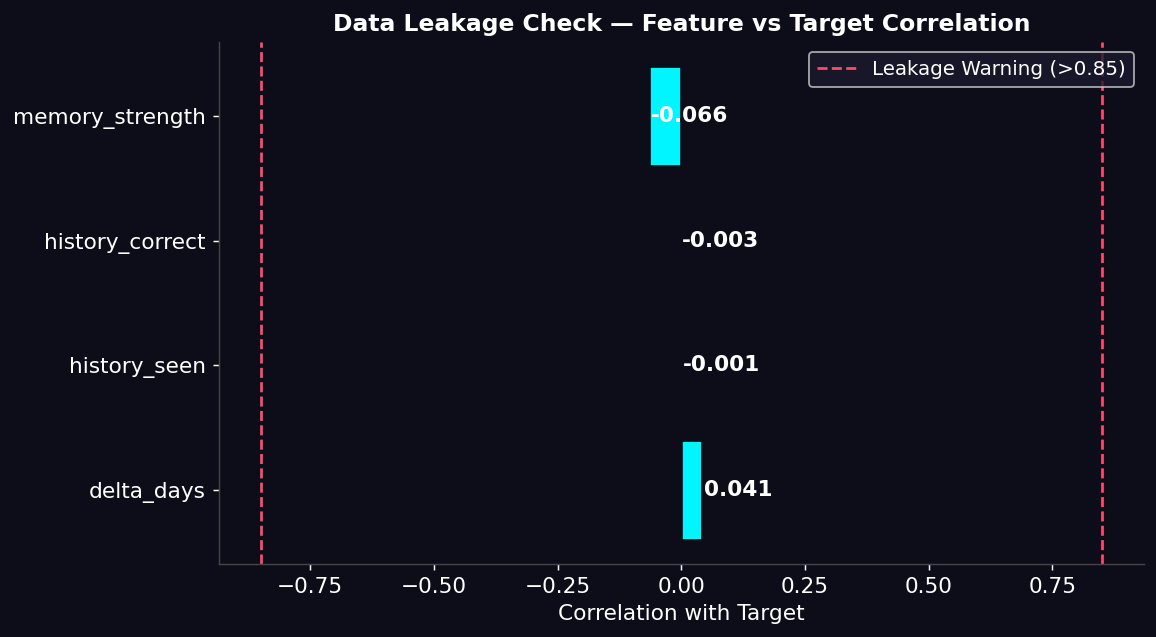

Leakage Check Results:
  delta_days               : 0.041  ->  Clean
  history_seen             : -0.001  ->  Clean
  history_correct          : -0.003  ->  Clean
  memory_strength          : -0.066  ->  Clean


In [13]:
feature_target_corr = df[feature_cols + ["forgotten"]].corr()["forgotten"].drop("forgotten")

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")

colors = ["#FF4B6E" if abs(v) > 0.85 else "#00F5FF" for v in feature_target_corr.values]
bars = ax.barh(feature_target_corr.index, feature_target_corr.values,
               color=colors, edgecolor="#0D0D1A", linewidth=1.5)

for bar, val in zip(bars, feature_target_corr.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color="white",
            fontsize=12, fontweight="bold")

ax.axvline(x=0.85,  color="#FF4B6E", linestyle="--", linewidth=1.5, label="Leakage Warning (>0.85)")
ax.axvline(x=-0.85, color="#FF4B6E", linestyle="--", linewidth=1.5)
ax.set_xlabel("Correlation with Target", color="white", fontsize=12)
ax.set_title("Data Leakage Check — Feature vs Target Correlation",
             color="white", fontsize=13, fontweight="bold")
ax.tick_params(colors="white", labelsize=12)
ax.legend(facecolor="#1A1A2E", labelcolor="white", fontsize=11)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    ax.spines[sp].set_color("#444")

plt.tight_layout()
plt.savefig("leakage_check.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

print("Leakage Check Results:")
for feat, corr in feature_target_corr.items():
    status = "LEAKAGE RISK" if abs(corr) > 0.85 else "Clean"
    print(f"  {feat:25s}: {corr:.3f}  ->  {status}")

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
  Model Comparison Chart
</h2>

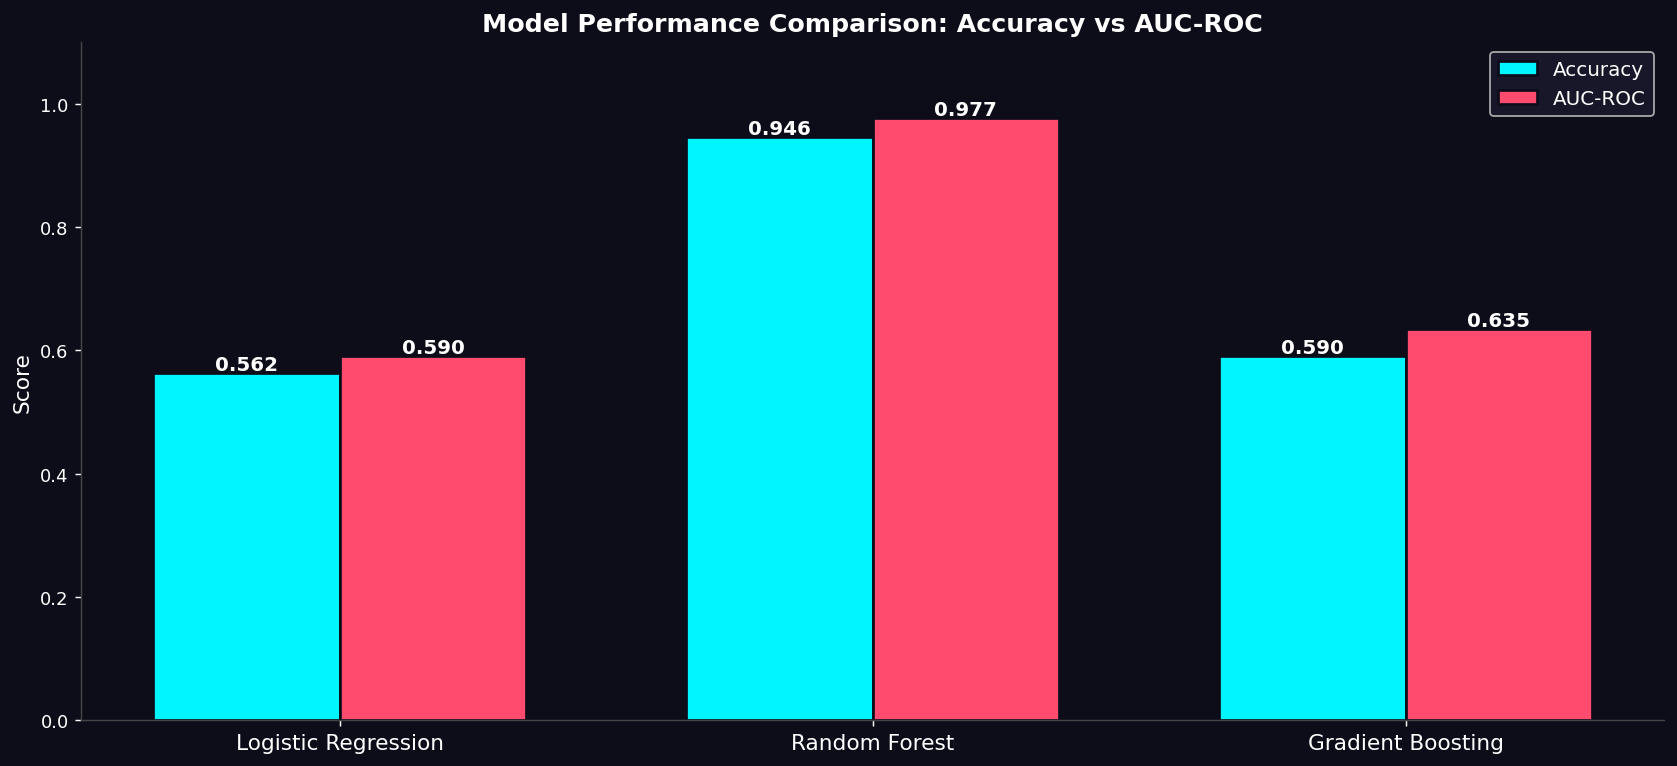

In [14]:
model_names = list(results.keys())
accuracies  = [results[m]["accuracy"] for m in model_names]
aucs        = [results[m]["auc"]      for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")

bars1 = ax.bar(x - width / 2, accuracies, width, label="Accuracy",
               color="#00F5FF", edgecolor="#0D0D1A", linewidth=1.5)
bars2 = ax.bar(x + width / 2, aucs, width, label="AUC-ROC",
               color="#FF4B6E", edgecolor="#0D0D1A", linewidth=1.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", color="white",
            fontsize=11, fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", color="white",
            fontsize=11, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(model_names, color="white", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score", color="white", fontsize=12)
ax.set_title("Model Performance Comparison: Accuracy vs AUC-ROC",
             color="white", fontsize=14, fontweight="bold")
ax.tick_params(colors="white")
ax.legend(facecolor="#1A1A2E", labelcolor="white", fontsize=11)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    ax.spines[sp].set_color("#444")

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
   ROC Curves
</h2>

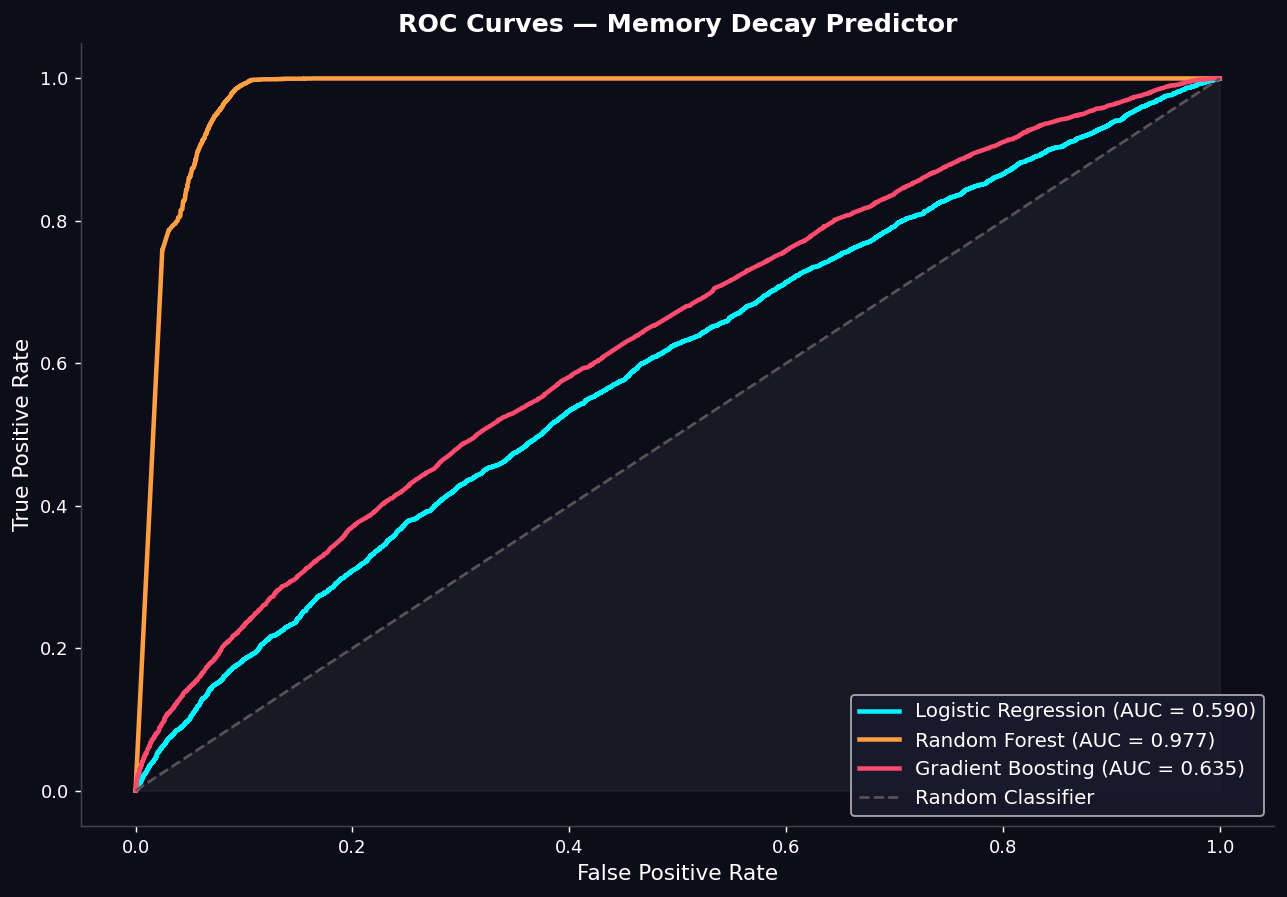

In [15]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")

roc_colors = ["#00F5FF", "#FF9F43", "#FF4B6E"]

for (name, res), color in zip(results.items(), roc_colors):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f"{name} (AUC = {res['auc']:.3f})")

ax.plot([0, 1], [0, 1], color="#555", linewidth=1.5,
        linestyle="--", label="Random Classifier")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="white")

ax.set_xlabel("False Positive Rate", color="white", fontsize=12)
ax.set_ylabel("True Positive Rate", color="white", fontsize=12)
ax.set_title("ROC Curves — Memory Decay Predictor",
             color="white", fontsize=14, fontweight="bold")
ax.tick_params(colors="white")
ax.legend(facecolor="#1A1A2E", labelcolor="white", fontsize=11, loc="lower right")
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    ax.spines[sp].set_color("#444")

plt.tight_layout()
plt.savefig("roc_curves.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Confusion Matrix (Best Model)
</h2>

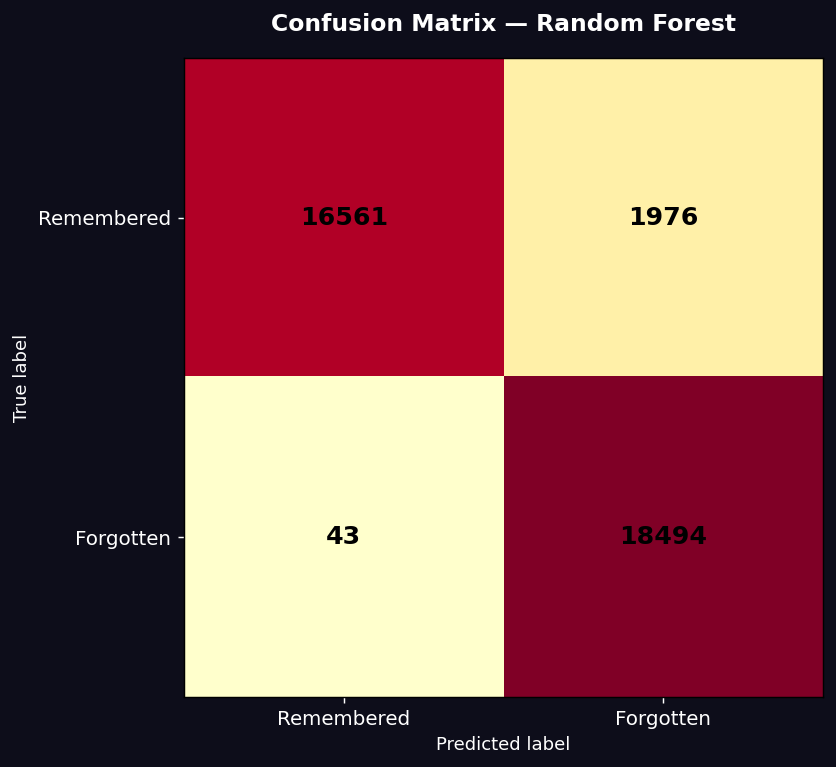


Best Model: Random Forest
              precision    recall  f1-score   support

  Remembered       1.00      0.89      0.94     18537
   Forgotten       0.90      1.00      0.95     18537

    accuracy                           0.95     37074
   macro avg       0.95      0.95      0.95     37074
weighted avg       0.95      0.95      0.95     37074



In [16]:
best_model_name = max(results, key=lambda m: results[m]["auc"])
best_result = results[best_model_name]

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")

cm = confusion_matrix(y_test, best_result["y_pred"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Remembered", "Forgotten"])
disp.plot(ax=ax, colorbar=False, cmap="YlOrRd")

ax.set_title(f"Confusion Matrix — {best_model_name}",
             color="white", fontsize=13, fontweight="bold", pad=15)
ax.tick_params(colors="white", labelsize=11)
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
for text in ax.texts:
    text.set_color("black")
    text.set_fontsize(14)
    text.set_fontweight("bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

print(f"\nBest Model: {best_model_name}")
print(classification_report(y_test, best_result["y_pred"],
                             target_names=["Remembered", "Forgotten"]))

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Feature Importance (Random Forest)</h2>

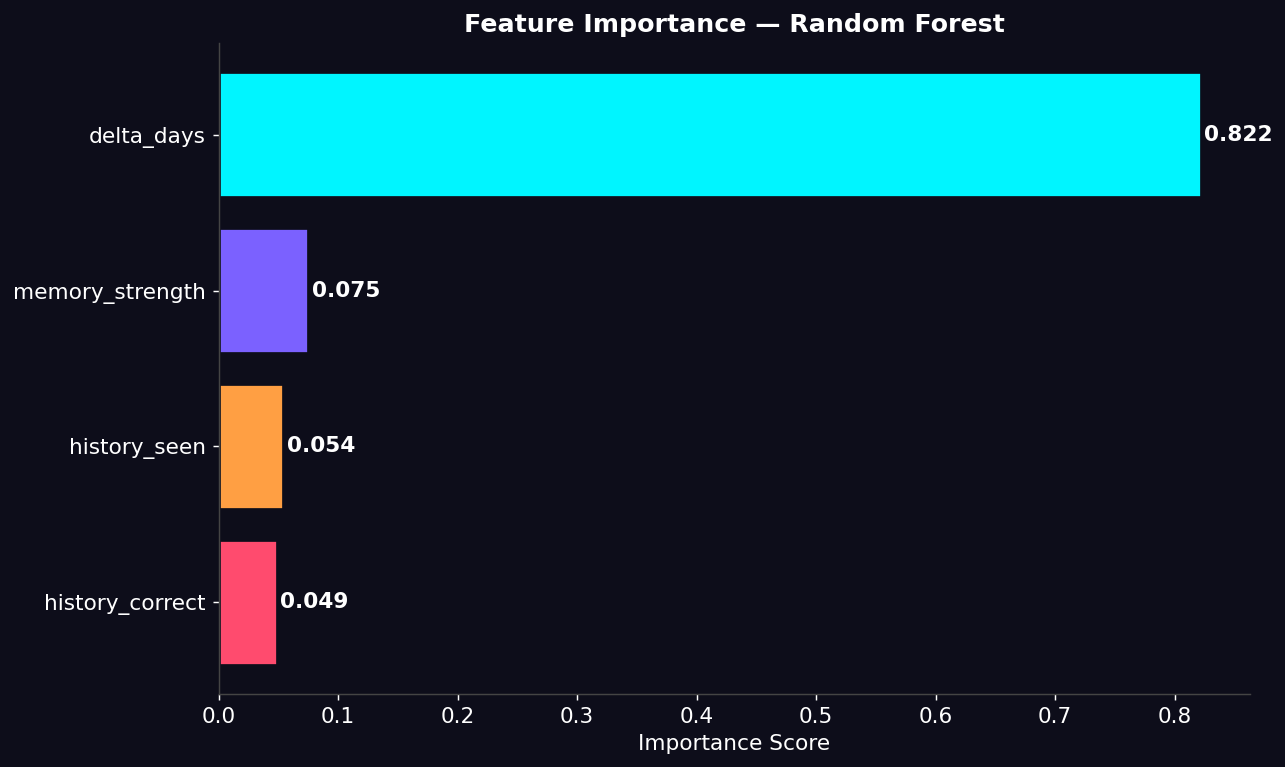

In [17]:
rf_model = results["Random Forest"]["model"]
importances = rf_model.feature_importances_
feature_names = feature_cols

sorted_idx = np.argsort(importances)[::-1]
sorted_names  = [feature_names[i] for i in sorted_idx]
sorted_values = importances[sorted_idx]

bar_colors = ["#00F5FF", "#7B61FF", "#FF9F43", "#FF4B6E"]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")

bars = ax.barh(sorted_names, sorted_values,
               color=bar_colors[:len(sorted_names)],
               edgecolor="#0D0D1A", linewidth=1.5)
for bar, val in zip(bars, sorted_values):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", color="white",
            fontsize=12, fontweight="bold")

ax.set_xlabel("Importance Score", color="white", fontsize=12)
ax.set_title("Feature Importance — Random Forest",
             color="white", fontsize=14, fontweight="bold")
ax.tick_params(colors="white", labelsize=12)
ax.invert_yaxis()
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)
for sp in ["bottom", "left"]:
    ax.spines[sp].set_color("#444")

plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

<h2 style="
text-align:center;
color:#1e3c72;
font-weight:800;
font-size:32px;
text-shadow:2px 2px 10px rgba(30,60,114,0.4);
letter-spacing:2px;">
 Live Prediction Example</h2>

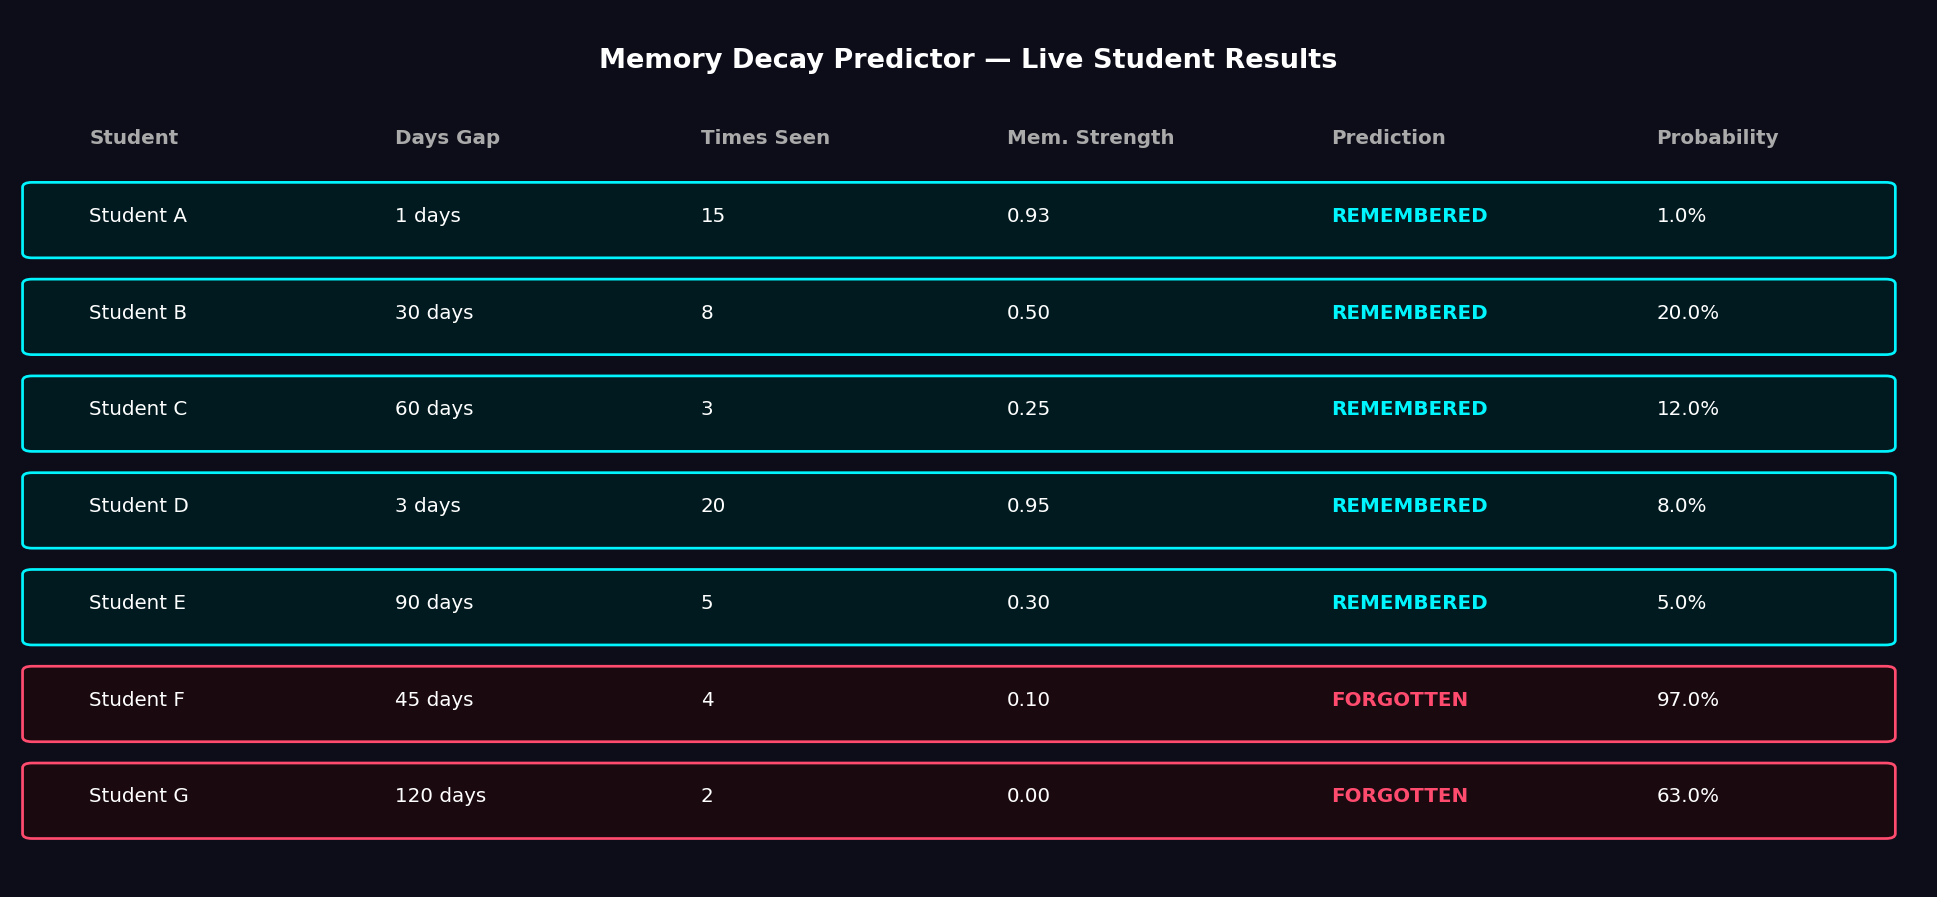

Prediction complete. Model used: Random Forest

Detailed Results:
  Student A  |   1 days | prob=0.010 | REMEMBERED
  Student B  |  30 days | prob=0.200 | REMEMBERED
  Student C  |  60 days | prob=0.120 | REMEMBERED
  Student D  |   3 days | prob=0.080 | REMEMBERED
  Student E  |  90 days | prob=0.050 | REMEMBERED
  Student F  |  45 days | prob=0.970 | FORGOTTEN
  Student G  | 120 days | prob=0.630 | FORGOTTEN


In [18]:
best_clf = results["Random Forest"]["model"]

students = [
    {"name": "Student A", "delta_days": 1,   "history_seen": 15, "history_correct": 14, "memory_strength": 0.93},
    {"name": "Student B", "delta_days": 30,  "history_seen": 8,  "history_correct": 4,  "memory_strength": 0.50},
    {"name": "Student C", "delta_days": 60,  "history_seen": 3,  "history_correct": 1,  "memory_strength": 0.25},
    {"name": "Student D", "delta_days": 3,   "history_seen": 20, "history_correct": 19, "memory_strength": 0.95},
    {"name": "Student E", "delta_days": 90,  "history_seen": 5,  "history_correct": 2,  "memory_strength": 0.30},
    {"name": "Student F", "delta_days": 45,  "history_seen": 4,  "history_correct": 1,  "memory_strength": 0.10},
    {"name": "Student G", "delta_days": 120, "history_seen": 2,  "history_correct": 0,  "memory_strength": 0.00},
]

predictions_list = []
for student in students:
    row = [[
        student["delta_days"],
        student["history_seen"],
        student["history_correct"],
        student["memory_strength"]
    ]]
    input_df     = pd.DataFrame(row, columns=feature_cols)
    input_scaled = scaler.transform(input_df)
    prob         = best_clf.predict_proba(input_scaled)[0][1]
    prediction   = "FORGOTTEN" if prob >= 0.5 else "REMEMBERED"
    predictions_list.append({**student, "prediction": prediction, "prob": prob})

fig, ax = plt.subplots(figsize=(15, 7))
fig.patch.set_facecolor("#0D0D1A")
ax.set_facecolor("#0D0D1A")
ax.axis("off")
ax.set_xlim(0, 10)
ax.set_ylim(0, len(predictions_list) + 2)

ax.text(5, len(predictions_list) + 1.5,
        "Memory Decay Predictor — Live Student Results",
        ha="center", va="center", fontsize=15,
        fontweight="bold", color="white")

headers   = ["Student", "Days Gap", "Times Seen", "Mem. Strength", "Prediction", "Probability"]
positions = [0.4, 2.0, 3.6, 5.2, 6.9, 8.6]

for header, pos in zip(headers, positions):
    ax.text(pos, len(predictions_list) + 0.7, header,
            ha="left", va="center", fontsize=11,
            fontweight="bold", color="#AAAAAA")

for i, s in enumerate(predictions_list):
    row_color = "#FF4B6E" if s["prediction"] == "FORGOTTEN" else "#00F5FF"
    bg_color  = "#1A0A10" if s["prediction"] == "FORGOTTEN" else "#001A1F"
    y_pos     = len(predictions_list) - i - 0.1

    ax.add_patch(mpatches.FancyBboxPatch(
        (0.1, y_pos - 0.38), 9.7, 0.68,
        boxstyle="round,pad=0.05",
        facecolor=bg_color, edgecolor=row_color, linewidth=1.5
    ))

    row_values = [
        s["name"],
        f"{s['delta_days']} days",
        str(s["history_seen"]),
        f"{s['memory_strength']:.2f}",
        s["prediction"],
        f"{s['prob']:.1%}"
    ]

    for val, pos in zip(row_values, positions):
        is_label  = val in ["FORGOTTEN", "REMEMBERED"]
        ax.text(pos, y_pos, val,
                ha="left", va="center", fontsize=11,
                color=row_color if is_label else "white",
                fontweight="bold" if is_label else "normal")

plt.tight_layout()
plt.savefig("live_predictions.png", bbox_inches="tight", facecolor="#0D0D1A")
plt.show()

print("Prediction complete. Model used:", best_model_name)
print("\nDetailed Results:")
for s in predictions_list:
    print(f"  {s['name']:10s} | {s['delta_days']:3d} days | prob={s['prob']:.3f} | {s['prediction']}")